<a href="https://colab.research.google.com/github/stephanie465337/Data-Science-Portfolio-C21/blob/main/Projects/Project%20Template.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Title - data_clean

##Problem Definition
Understand the project's objectives from a business viewpoint.

- What is the Business Problem?  Often some variant of saving time, saving money, and/or making money.
- What Data Science Problem is this? ( Supervised or Unsupervised )
- If Supervised ...
  - How did you determine what is the target? What is the Target?
  - What statistical data type is the target: Numerical or Categorical?
  - Would this be a Classification or a Regression problem?
- If Unsupervised ...
  - What kind of clustering problem?

This is a Supervised/Unsupervised Classification/Regression/Clustering problem and we'll be using the BLANK model to make the predictions. (Additional middle example: We'll also be using Ridge and Lasso regularization techniques to reduce overfitting and for feature selection.) Our performance metric will be BLANK.


##Data Collection
Gather relevant data. If data are already available, understand how data were collected.

- Where is the data source located: local file, database, website, API, other?
- Where is the data dictionary?
- How many bytes ( KB, MB, GB, TB ) is the data set?
- What tools did/would you use to get and read the data?

In [ ]:
import pandas                as pd
import numpy                 as np
import matplotlib.pyplot     as plt
import seaborn               as sns
import statsmodels.api       as sm
import duckdb
import re

from sklearn                 import datasets
from sklearn                 import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.linear_model    import LinearRegression
from sklearn.metrics         import mean_squared_error
from sklearn.preprocessing   import StandardScaler
from sklearn.linear_model    import Ridge
from sklearn.linear_model    import Lasso
from google.colab            import userdata; import os

In [ ]:
url = 'https://ddc-datascience.s3.amazonaws.com/Projects/Project.2-Housing/Data/Housing.Data.csv'
url

'https://ddc-datascience.s3.amazonaws.com/Projects/Project.2-Housing/Data/Housing.Data.csv'

In [ ]:
df = pd.read_csv(url)
df

,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,905101070,20,RL,62.0,14299,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,7,2007,WD,Normal,115400
1,905101330,90,RL,72.0,10791,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,Shed,500,10,2006,WD,Normal,90000
2,903454090,50,RM,50.0,9000,Pave,NaN,Reg,Bnk,AllPub,...,0,NaN,NaN,NaN,0,12,2007,WD,Normal,141000
3,533244030,60,FV,68.0,7379,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,254000
4,909252020,70,RL,60.0,7200,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,4,2009,WD,Normal,155000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2632,903231070,50,RM,52.0,6240,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,Shed,400,9,2006,WD,Normal,114500
2633,906201021,80,RL,74.0,10778,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,7,2009,WD,Normal,162000
2634,533253070,120,RL,61.0,3782,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2009,WD,Normal,211500
2635,527376100,20,RL,78.0,10140,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,8,2009,WD,Normal,165000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2637 entries, 0 to 2636
Data columns (total 81 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   PID              2637 non-null   int64  
 1   MS SubClass      2637 non-null   int64  
 2   MS Zoning        2637 non-null   object 
 3   Lot Frontage     2188 non-null   float64
 4   Lot Area         2637 non-null   int64  
 5   Street           2637 non-null   object 
 6   Alley            180 non-null    object 
 7   Lot Shape        2637 non-null   object 
 8   Land Contour     2637 non-null   object 
 9   Utilities        2637 non-null   object 
 10  Lot Config       2637 non-null   object 
 11  Land Slope       2637 non-null   object 
 12  Neighborhood     2637 non-null   object 
 13  Condition 1      2637 non-null   object 
 14  Condition 2      2637 non-null   object 
 15  Bldg Type        2637 non-null   object 
 16  House Style      2637 non-null   object 
 17  Overall Qual  

##Data Cleaning

- How can/did you discover how many rows?
- How can/did you discover how many columns?
- How can/did you discover if there are any unique identifiers and how would/did you handle them?
- How can/did you discover if there are any nulls and how would/did you handle them?
- If Supervised, how can/did you discover if there are any nulls in your target and how would/did you handle them?
- How can/did you discover if there are any duplicates and how would/did you handle them?
- How can/did you discover if there are any missing values and how would/did you handle them?
- How can/did you discover if there are any nested fields and how would/did you handle them?

In [ ]:
df.shape

(2637, 81)

###Columns

In [ ]:
#To find the indicies of columns
#list(enumerate(df.columns.to_list(), start=100))

In [ ]:
df.dtypes.value_counts()

,count
object,43
int64,27
float64,11


In [ ]:
pd.set_option('display.max_rows', 100) #Up to 100
df.dtypes.sort_values()

,0
PID,int64
Low Qual Fin SF,int64
Gr Liv Area,int64
Full Bath,int64
Half Bath,int64
Bedroom AbvGr,int64
Kitchen AbvGr,int64
TotRms AbvGrd,int64
Fireplaces,int64
Wood Deck SF,int64


####Target

In [ ]:
#Assign Target to target variable
target = 'TargetName' ##Replace w/TargetName for template
target

'SalePrice'

In [ ]:
#View target
df[target]

,SalePrice
0,115400
1,90000
2,141000
3,254000
4,155000
...,...
2632,114500
2633,162000
2634,211500
2635,165000


In [ ]:
#Look to see if there are nulls in target
df[target].isnull().sum()

np.int64(0)

In [ ]:
#Check the dtype
df[target].dtype

dtype('int64')

In [ ]:
#Confirm target does not have a O value
df[target].min()

12789

####Unique IDs

In [ ]:
#Looking for identifier columns
(df.index.size-df.nunique()).sort_values().head()

,0
PID,0
Lot Area,838
Gr Liv Area,1421
Bsmt Unf SF,1557
1st Flr SF,1615


In [ ]:
#What is this for?
#Used where later on?
cols_drop = ['UniqueIDs'] ##Replace w/UniqueIDs for template
cols_drop

['PID']

In [ ]:
#Drop unique identifiers
df.drop(columns=['UniqueIDs'], inplace=True) ##Replace w/UniqueIDs for template
df

,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,20,RL,62.0,14299,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,MnPrv,NaN,0,7,2007,WD,Normal,115400
1,90,RL,72.0,10791,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,Shed,500,10,2006,WD,Normal,90000
2,50,RM,50.0,9000,Pave,NaN,Reg,Bnk,AllPub,Inside,...,0,NaN,NaN,NaN,0,12,2007,WD,Normal,141000
3,60,FV,68.0,7379,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,254000
4,70,RL,60.0,7200,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,MnPrv,NaN,0,4,2009,WD,Normal,155000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2632,50,RM,52.0,6240,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,MnPrv,Shed,400,9,2006,WD,Normal,114500
2633,80,RL,74.0,10778,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,7,2009,WD,Normal,162000
2634,120,RL,61.0,3782,Pave,NaN,IR1,Lvl,AllPub,CulDSac,...,0,NaN,NaN,NaN,0,9,2009,WD,Normal,211500
2635,20,RL,78.0,10140,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,MnPrv,NaN,0,8,2009,WD,Normal,165000


####Features

In [ ]:
#View all columns in a sorted list
# df.columns.sort_values().to_list()

In [ ]:
#Rows with nulls in each
# df.isnull().sum().sort_values()*1000

In [ ]:
#Look for int, float, object totals at the bottom
# df.info()

#####Categorical

Likely

In [ ]:
#Filter is looking for values less than 20
filter = df.nunique() < 20

#These are most likely categorical but not definite
df.nunique()[ filter ].sort_values(ascending = False)

,0
Exterior 2nd,17
Exterior 1st,16
MS SubClass,16
Mo Sold,12
TotRms AbvGrd,12
Pool Area,12
Sale Type,10
Overall Qual,10
Condition 1,9
Overall Cond,9


######Objects

In [ ]:
df_obj = df.select_dtypes(include=['object'])
df_obj

,MS Zoning,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,Neighborhood,Condition 1,...,Garage Type,Garage Finish,Garage Qual,Garage Cond,Paved Drive,Pool QC,Fence,Misc Feature,Sale Type,Sale Condition
0,RL,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Sawyer,Feedr,...,Detchd,Unf,TA,TA,N,NaN,MnPrv,NaN,WD,Normal
1,RL,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Sawyer,Norm,...,CarPort,Unf,TA,TA,Y,NaN,NaN,Shed,WD,Normal
2,RM,Pave,NaN,Reg,Bnk,AllPub,Inside,Gtl,IDOTRR,Norm,...,Detchd,Unf,TA,TA,P,NaN,NaN,NaN,WD,Normal
3,FV,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Somerst,Norm,...,Attchd,RFn,TA,TA,Y,NaN,NaN,NaN,WD,Normal
4,RL,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,SWISU,Feedr,...,Detchd,RFn,TA,TA,Y,NaN,MnPrv,NaN,WD,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2632,RM,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,BrkSide,Norm,...,Detchd,Unf,TA,TA,Y,NaN,MnPrv,Shed,WD,Normal
2633,RL,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,SawyerW,Feedr,...,Attchd,Unf,TA,TA,Y,NaN,NaN,NaN,WD,Normal
2634,RL,Pave,NaN,IR1,Lvl,AllPub,CulDSac,Gtl,Greens,Norm,...,Attchd,Fin,TA,TA,Y,NaN,NaN,NaN,WD,Normal
2635,RL,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NWAmes,Norm,...,Attchd,RFn,TA,TA,Y,NaN,MnPrv,NaN,WD,Normal


#####Numerical

######Integers (discrete)

In [ ]:
df_int = df.select_dtypes(include=['int64']) #64 subject to change
df_int

,MS SubClass,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,1st Flr SF,2nd Flr SF,Low Qual Fin SF,Gr Liv Area,...,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice
0,20,14299,4,3,1964,1964,1005,0,0,1005,...,0,0,0,0,0,0,0,7,2007,115400
1,90,10791,4,5,1967,1967,1296,0,0,1296,...,0,0,0,0,0,0,500,10,2006,90000
2,50,9000,6,6,1937,1950,780,595,0,1375,...,0,162,0,0,126,0,0,12,2007,141000
3,60,7379,8,5,2000,2000,975,873,0,1848,...,280,184,0,0,0,0,0,4,2010,254000
4,70,7200,7,9,1936,2007,575,560,0,1135,...,256,0,0,0,0,0,0,4,2009,155000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2632,50,6240,6,6,1934,1950,816,0,360,1176,...,112,0,0,0,0,0,400,9,2006,114500
2633,80,10778,7,6,1990,1991,1061,0,0,1061,...,114,36,0,0,0,0,0,7,2009,162000
2634,120,3782,8,5,1981,1981,1226,0,0,1226,...,133,78,0,0,0,0,0,9,2009,211500
2635,20,10140,6,5,1974,1974,1350,0,0,1350,...,0,0,0,0,0,0,0,8,2009,165000


In [ ]:
#Look for nulls
df_int.isnull().sum().sort_values(ascending = False)

,0
MS SubClass,0
Lot Area,0
Overall Qual,0
Overall Cond,0
Year Built,0
Year Remod/Add,0
1st Flr SF,0
2nd Flr SF,0
Low Qual Fin SF,0
Gr Liv Area,0


In [ ]:
#Verify no nulls in feature variable
df_int['Prediction'].isna().sum() ##Replace w/Prediction for template

np.int64(0)

In [ ]:
df_int.nunique().sort_values()

,0
Half Bath,3
Kitchen AbvGr,4
Full Bath,5
Fireplaces,5
Yr Sold,5
Bedroom AbvGr,7
Overall Cond,9
Overall Qual,10
Mo Sold,12
Pool Area,12


######Float (continuous)

In [ ]:
df_flt = df.select_dtypes(include=['float64'])
df_flt

,Lot Frontage,Mas Vnr Area,BsmtFin SF 1,BsmtFin SF 2,Bsmt Unf SF,Total Bsmt SF,Bsmt Full Bath,Bsmt Half Bath,Garage Yr Blt,Garage Cars,Garage Area
0,62.0,0.0,513.0,144.0,348.0,1005.0,1.0,0.0,1964.0,2.0,440.0
1,72.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1967.0,2.0,516.0
2,50.0,0.0,0.0,0.0,780.0,780.0,0.0,0.0,1979.0,1.0,544.0
3,68.0,0.0,484.0,0.0,491.0,975.0,1.0,0.0,2000.0,2.0,592.0
4,60.0,0.0,350.0,210.0,0.0,560.0,1.0,0.0,1971.0,2.0,576.0
...,...,...,...,...,...,...,...,...,...,...,...
2632,52.0,0.0,0.0,0.0,816.0,816.0,0.0,0.0,1985.0,2.0,528.0
2633,74.0,0.0,460.0,286.0,308.0,1054.0,1.0,0.0,1990.0,2.0,462.0
2634,61.0,0.0,960.0,0.0,266.0,1226.0,1.0,0.0,1981.0,2.0,484.0
2635,78.0,174.0,0.0,0.0,1064.0,1064.0,0.0,0.0,1974.0,2.0,478.0


In [ ]:
df_flt.isnull().sum().sort_values(ascending = False)

,0
Lot Frontage,449
Garage Yr Blt,147
Mas Vnr Area,23
Bsmt Half Bath,2
Bsmt Full Bath,2
BsmtFin SF 1,1
BsmtFin SF 2,1
Total Bsmt SF,1
Bsmt Unf SF,1
Garage Cars,1


###Rows

In [ ]:
#Rows with nulls
df.isnull().any(axis = 1).sum()

np.int64(2637)

In [ ]:
#Missing rows
df.isnull().sum().sort_values()

,0
MS SubClass,0
MS Zoning,0
Lot Area,0
Street,0
Land Contour,0
Lot Shape,0
Lot Config,0
Utilities,0
Condition 1,0
Condition 2,0


In [ ]:
#Duplicate rows
df.duplicated().sum()

np.int64(0)

###Assigning Target and Features

Begin with one feature.

Numerical. No nulls. Lots of unique values.

In [ ]:
features = ['Lot Feature'] ##Replace w/Feature for template
features

['Lot Area']

In [ ]:
tf = [target] + features
tf

['SalePrice', 'Lot Area']

#Push to HuggingFace

In [ ]:
df_clean = df_int[tf].copy()

## Authenticate to Hugging Face


In [ ]:
#Retrieve the token from Colab's secret manager
os.environ["HF_TOKEN"] = userdata.get('hf_token')
_ = os.environ["HF_TOKEN"]
f"{_[:5]} ... {_[-3:]}"

In [ ]:
os.environ["HF_ACCOUNT"] = userdata.get('hf_account')
hf_account = os.environ["HF_ACCOUNT"]
hf_account

In [ ]:
hf_repo = "Data_Science-21"
os.environ["HF_REPO"] = hf_repo
hf_repo

In [ ]:
#Log in automatically without an interactive prompt
!hf auth login --token $HF_TOKEN

## Push to Hugging Face


In [ ]:
%%capture hf_upload
%%bash

hf upload \
  --type dataset \
  ${HF_ACCOUNT}/${HF_REPO} \
  FileName.parquet #Update FileName

In [ ]:
print(hf_upload.stdout)

In [ ]:
%%capture hf_upload
%%bash

hf upload \
  --type dataset \
  ${HF_ACCOUNT}/${HF_REPO} \
  FileName.csv #Update FileName

In [ ]:
print(hf_upload.stdout)

## Read parquet from Hugging Face


In [ ]:
#Construct the base Hugging Face URL for your dataset files
hf_url = f"https://huggingface.co/datasets/{hf_account}/{hf_repo}/resolve/main/FileName.parquet" #Update FileName
hf_url

In [ ]:
df3 = pd.read_parquet(hf_url)
df3.shape

In [ ]:
df3.iloc[:,:5].info()

#Title - data_model

##Exploratory Data Analysis (EDA)

- If Supervised, what data type is your target?  What does that suggest for the type of ML process you will use?
- What is the distribution of values for your target?
- How can/did you discover which fields are Categorical?
- How can/did you discover which fields are Numerical?
- For each field, what is the distribution?
- How can/did you discover the relationship between any two variables?




###Correlation

In [ ]:
#Create a correlation matrix with the absolute values to 2 decimals
corr = df_clean.corr().abs().round(2)
corr

,SalePrice,Lot Area
SalePrice,1.00,0.27
Lot Area,0.27,1.00


In [ ]:
ones = np.ones_like(corr, dtype = bool)
mask = np.tril(ones, k = -1)
lower_triangle_corr = corr.where(mask)
lower_triangle_corr

,SalePrice,Lot Area
SalePrice,NaN,NaN
Lot Area,0.27,NaN


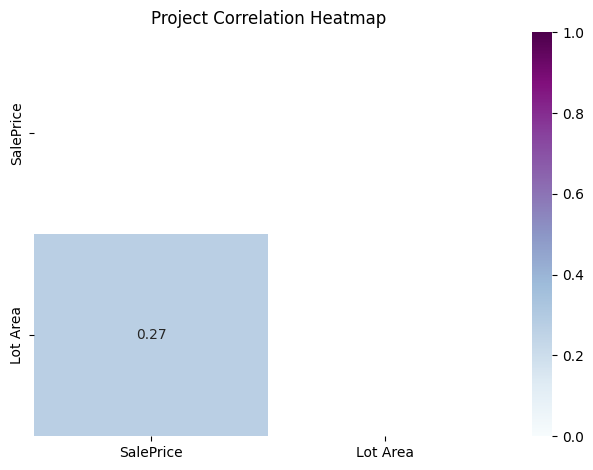

In [ ]:
sns.heatmap(
    data=lower_triangle_corr,
    annot=True, #Turns on the numbers in the boxes
    cmap='BuPu',
    vmin=0,
    vmax=1,
    # annot_kws={"size": 12}, #Sets the font size of those numbers to 12
    # fmt=".2f" #Formats the numbers to 2 decimal places
)

plt.title("Project Correlation Heatmap") #Update 'Project' with actual project definition

plt.tight_layout()
# plt.savefig("Corr.png")
plt.show()

In [ ]:
lower_triangle_corr[target].dropna().sort_values(ascending=False)

,SalePrice
Lot Area,0.27


In [ ]:
#Features
# What does this do?
#  Checks the r. What does the r represent?

(
# lower_triangle_corr
  # .drop( columns = [ target ] )
  # .unstack()
  # .dropna()
  # .to_frame()
  # .rename( columns={0:"r"} )
  # .query( "r > 0.90")
  # .sort_values( by = "r", ascending=False )
  # .reset_index()
)

###Boxplot

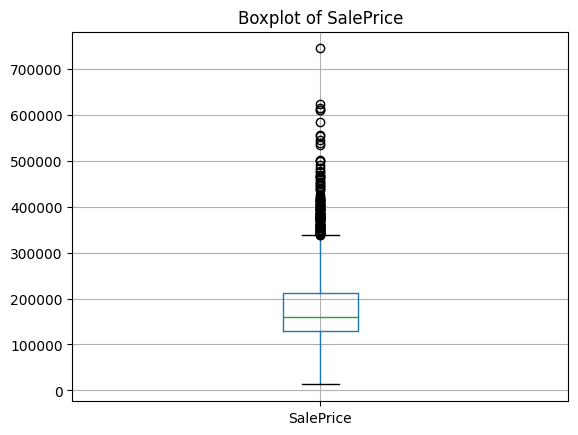

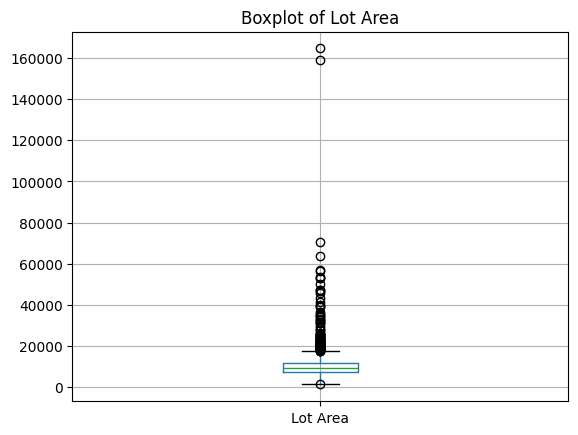

In [ ]:
#Run to know what you should plot below
for col in df_clean.columns:
    plt.figure()  # Creates a new, clean figure window
    df_clean.boxplot(column=col)
    plt.title(f'Boxplot of {col}')
    plt.show()

###Histogram

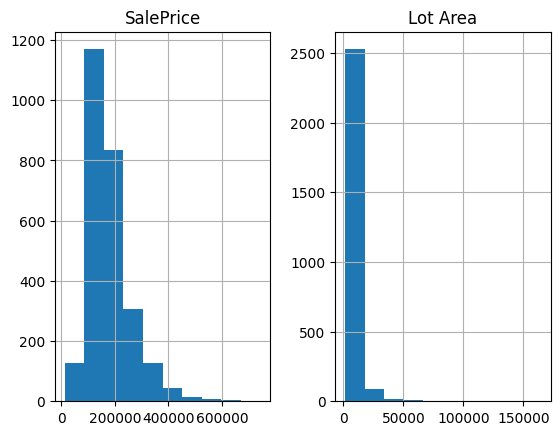

In [ ]:
#Use comments as needed
# n = int(2637**(1/2)) # bins

df_clean.hist() # figsize=(10, 10), bins=n, color='lightblue', edgecolor='black')

# plt.tight_layout()
# plt.savefig("Hist.png")
plt.show()

##Processing
Use modeling techniques to gain useful insights into data and meet objectives of the project.

- What questions did you ask to determine which ML process to use?
- How did/can you determine what performance metric to use?  What others could you have used?  Which metrics might not be appropriate?
- How did/can you account for the variance/bias trade-off?

Models we've learned so far:
- Naive Bayes
- Gaussian Naive Bayes
- Linear Regession
- Ridge Regulation
- Lasso Regulation

In [ ]:
X = df_clean.drop(target, axis=1)
y = df_clean[target]

In [ ]:
def #Metric

In [ ]:
#Calculate CV RMSE
n = 500
results = np.zeros(n)

for idx in range(n):
  #Train, test split
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25)

  #Standard scale only training features
  scaler = StandardScaler()
  scaler.fit(X_train)
  X_train = scaler.transform(X_train)

  #Scale testing features
  X_test = scaler.transform(X_test)

  #Create the model
  my_fit = LinearRegression()

  #Fit regression
  my_fit.fit(X_train, y_train)

  #Predict
  y_pred = my_fit.predict(X_test)

  #Calculate and record performance metric
  results[idx] = rmspe(y_test,y_pred)

results.mean()

##Data Visualization/Communication of Results
Communicate results of analysis. Draw meaningful conclusions.

- What plots did you use?  What did they show? What other visualizations could you have used?
- What could/should have been done to improve your performance metric?
- What constraints did you have while doing this project?  How could they be alleviated/mitigated?
- Had you more resources, what else could you have done?
- What are your next steps?


Whays to use data:
- Predict
- Cluster
- Optimize
- Detect
- Recommend

Include final graphs/images used in the presentation final.

##Conclusion and Future Work

Example:
- Conclusions
  - Not a good model with 60%+ error
  - The results histogram suggests 3 distinct populations
- Future Work
  - Include more numerical features